In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = Path("../data/data")

# Airbnb Listings — Exploratory Data Analysis

Exploratory analysis of the Inside Airbnb snapshot used as the **revenue** data source for the property-pricing project (see the vault note `02 - Data Sources/Inside Airbnb.md`).

**Goals**
- Understand the structure, quality, and coverage of the raw Inside Airbnb export (`listings`, `neighbourhoods`, `calendar`, `reviews`).
- Characterize price, availability, and review patterns at the listing level.
- Surface data-quality issues and open questions before this feeds the hedonic revenue model.

> **⚠️ Finding to confirm with the team:** the `neighbourhood_cleansed` / `neighbourhood_group_cleansed` values in this snapshot (Itaim Bibi, Pinheiros, Moema, Vila Mariana, Butantã, ...) are **São Paulo** neighborhoods, not Rio de Janeiro. The rest of the project (README, ITBI/Data.Rio, ISP-RJ) is scoped to Rio de Janeiro. See the "Geographic scope check" section below — this is flagged as an open question in the Obsidian vault.

In [2]:
df_listings = pd.read_csv(DATA_DIR / "listings.csv", low_memory=False)
df_neighbourhoods = pd.read_csv(DATA_DIR / "neighbourhoods.csv")

print(f"listings:       {df_listings.shape}")
print(f"neighbourhoods: {df_neighbourhoods.shape}")

listings:       (42354, 90)
neighbourhoods: (96, 2)


In [3]:
df_listings.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,4917,https://www.airbnb.com/rooms/4917,20260614072545,2026-06-16,city scrape,Resort Condo Near Av. Paulista,"Comfortable 2 bedrooms (1 master suite), 2 bat...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,5618,...,4.94,4.97,4.67,NaN,NaN,1,1,0,0,0.46
1,54614,https://www.airbnb.com/rooms/54614,20260614072545,2026-06-16,city scrape,Nice area/Cozy flat/ Building rooftop pool,"Small, modern and charming flat. Cozy standard...",NaN,https://a0.muscache.com/pictures/31da1f7a-2d33...,256576,...,4.99,4.97,4.93,NaN,NaN,1,1,0,0,1.63
2,82935,https://www.airbnb.com/rooms/82935,20260614072545,2026-06-14,city scrape,Oscar Freire - Hospital das Clínicas e Nu Bank,I live in a 3-bedroom apartment in the most re...,NaN,https://a0.muscache.com/pictures/1cb69bb6-bb68...,451565,...,4.98,4.98,4.86,NaN,NaN,1,0,1,0,0.61


## 1. Dataset overview

In [4]:
print(f"Rows: {df_listings.shape[0]:,}  |  Columns: {df_listings.shape[1]}")
df_listings.dtypes.value_counts()

Rows: 42,354  |  Columns: 90


float64    37
object     29
int64      24
Name: count, dtype: int64

## 2. Data quality: missing values

Several columns are entirely empty in this export (e.g. `host_since`, `license`, `instant_bookable`) — these need to come from another source or scrape before modeling.

13 columns are 100% empty in this export:
['host_total_listings_count', 'host_since', 'neighbourhood', 'host_verifications', 'calendar_updated', 'host_neighbourhood', 'host_thumbnail_url', 'neighborhood_overview', 'instant_bookable', 'license', 'host_response_time', 'host_response_rate', 'host_acceptance_rate']


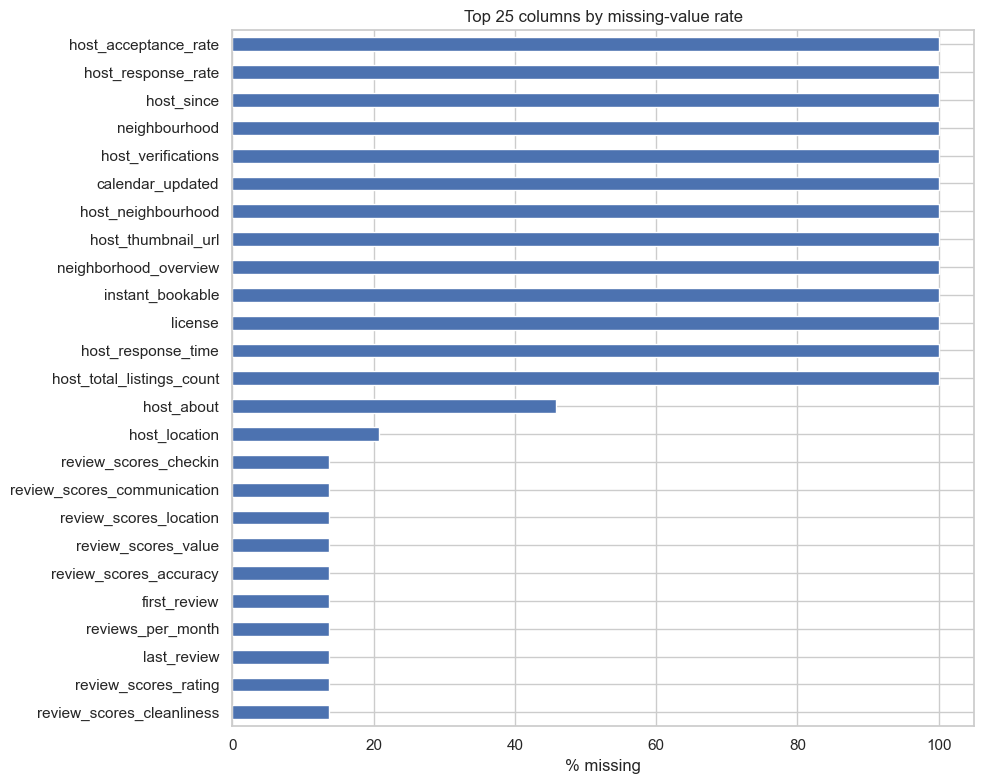

In [5]:
missing_pct = (df_listings.isna().mean() * 100).sort_values(ascending=False)
fully_empty = missing_pct[missing_pct == 100].index.tolist()
print(f"{len(fully_empty)} columns are 100% empty in this export:")
print(fully_empty)

fig, ax = plt.subplots(figsize=(10, 8))
missing_pct.head(25).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% missing")
ax.set_title("Top 25 columns by missing-value rate")
plt.tight_layout()
plt.show()

## 3. Geographic scope check

The project (README, ITBI/Data.Rio, ISP-RJ) is scoped to **Rio de Janeiro**. This snapshot's neighborhood names and coordinates need to be checked against that assumption.

In [6]:
print("Unique neighbourhood_group_cleansed values:")
print(sorted(df_listings["neighbourhood_group_cleansed"].dropna().unique()))

print("\nTop 15 neighbourhood_cleansed by listing count:")
print(df_listings["neighbourhood_cleansed"].value_counts().head(15))

lat_min, lat_max = df_listings["latitude"].min(), df_listings["latitude"].max()
lon_min, lon_max = df_listings["longitude"].min(), df_listings["longitude"].max()
print(f"\nBounding box: lat [{lat_min:.3f}, {lat_max:.3f}], lon [{lon_min:.3f}, {lon_max:.3f}]")
print("(Rio de Janeiro is roughly lat -23.0..-22.75, lon -43.8..-43.1;"
      " São Paulo is roughly lat -23.9..-23.4, lon -46.9..-46.4)")

Unique neighbourhood_group_cleansed values:
['Aricanduva-Formosa-Carrao', 'Butanta', 'Campo Limpo', 'Capela Do Socorro', 'Casa Verde-Limao-Cachoeirinha', 'Cidade Ademar', 'Cidade Tiradentes', 'Ermelino Matarazzo', 'Freguesia-Brasilandia', 'Guaianases', 'Ipiranga', 'Itaim Paulista', 'Itaquera', 'Jabaquara', 'Jacana-Tremembe', 'Lapa', 'M Boi Mirim', 'Mooca', 'Parelheiros', 'Penha', 'Perus-Anhanguera', 'Pinheiros', 'Pirituba-Jaragua', 'Santana-Tucuruvi', 'Santo Amaro', 'Sao Mateus', 'Sao Miguel', 'Sapopemba', 'Se', 'Vila Maria-Vila Guilherme', 'Vila Mariana', 'Vila Prudente']

Top 15 neighbourhood_cleansed by listing count:
neighbourhood_cleansed
Itaim Bibi         4382
Republica          3705
Jardim Paulista    3500
Moema              2857
Pinheiros          2838
Vila Mariana       2722
Bela Vista         2459
Perdizes           1979
Consolacao         1927
Santo Amaro        1862
Campo Belo         1404
Bras                845
Saude               810
Santa Cecilia       745
Liberdade   

**Result:** the neighborhood names (Itaim Bibi, República, Jardim Paulista, Moema, Pinheiros, ...) and the coordinate bounding box both match **São Paulo**, not Rio de Janeiro. This is a data-scope mismatch with the rest of the project and is logged as an open question in `02 - Data Sources/Inside Airbnb.md`.

## 4. Snapshot metadata

In [7]:
print("last_scraped values:", df_listings["last_scraped"].unique())
print("source values:", df_listings["source"].unique())

last_scraped values: ['2026-06-16' '2026-06-14' '2026-06-15']
source values: ['city scrape']


## 5. Price cleaning

`price` is a string like `"$540.43"`. Convert it to a numeric column before any analysis.

In [8]:
def clean_price(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .replace("nan", np.nan)
        .astype(float)
    )


df_listings["price_clean"] = clean_price(df_listings["price"])

print(df_listings["price_clean"].describe())
print(f"\nMissing price: {df_listings['price_clean'].isna().mean():.1%}")

count    41832.000000
mean       418.046308
std        817.571526
min         11.530000
25%        250.000000
50%        331.000000
75%        429.502500
max      57127.000000
Name: price_clean, dtype: float64

Missing price: 1.2%


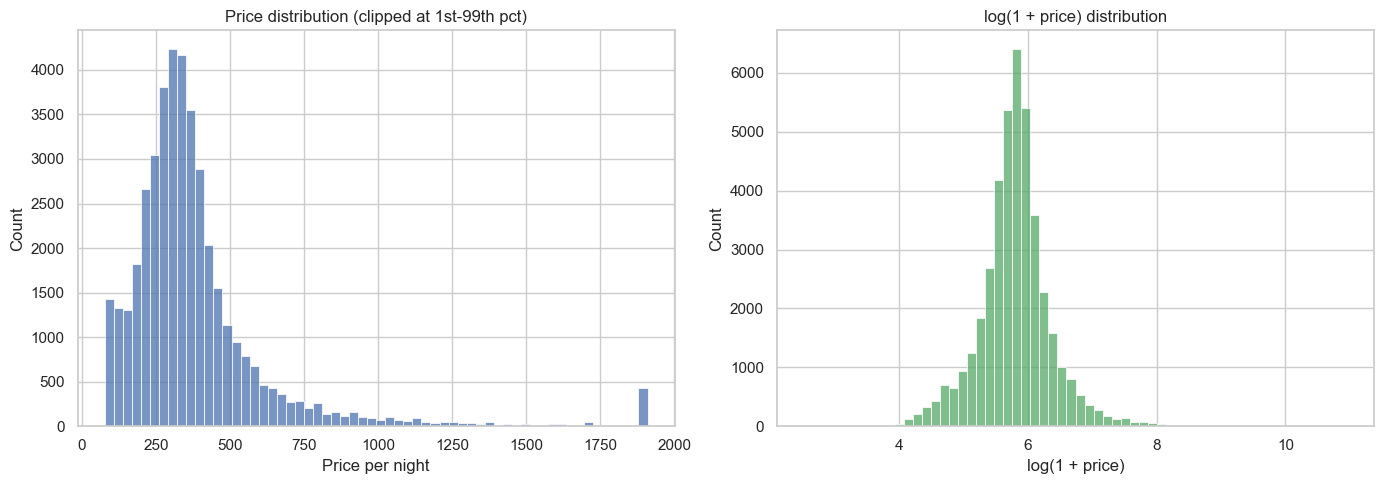

In [9]:
p1, p99 = df_listings["price_clean"].quantile([0.01, 0.99])
price_trimmed = df_listings["price_clean"].clip(lower=p1, upper=p99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(price_trimmed, bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Price distribution (clipped at 1st-99th pct)")
axes[0].set_xlabel("Price per night")

sns.histplot(np.log1p(df_listings["price_clean"].dropna()), bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("log(1 + price) distribution")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.show()

## 6. Room type & property type

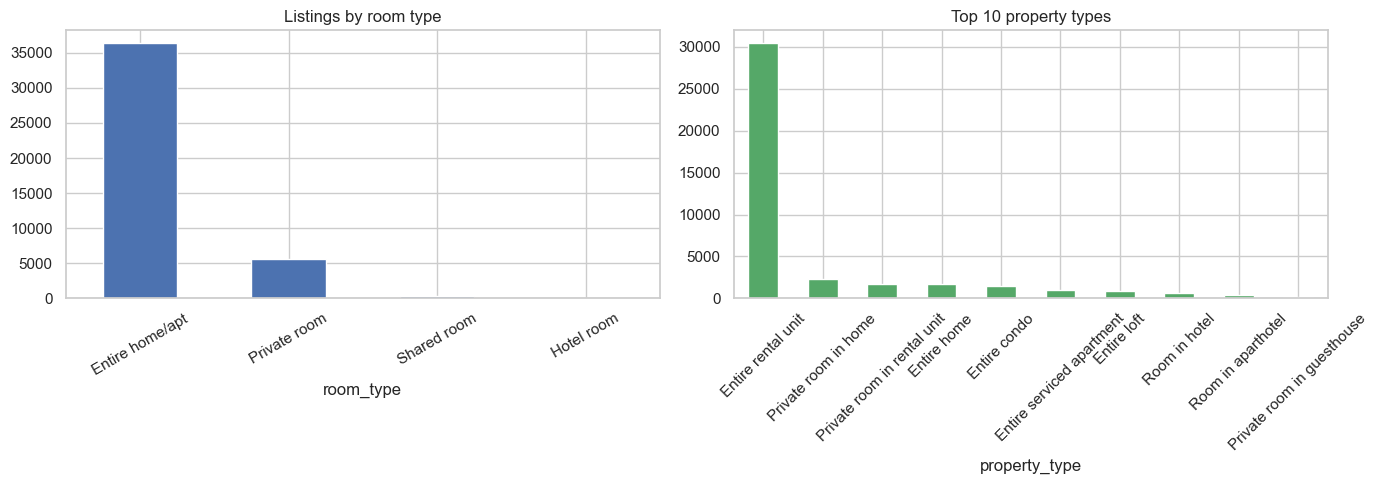

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_listings["room_type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Listings by room type")
axes[0].tick_params(axis="x", rotation=30)

df_listings["property_type"].value_counts().head(10).plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Top 10 property types")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Price by room type and neighborhood

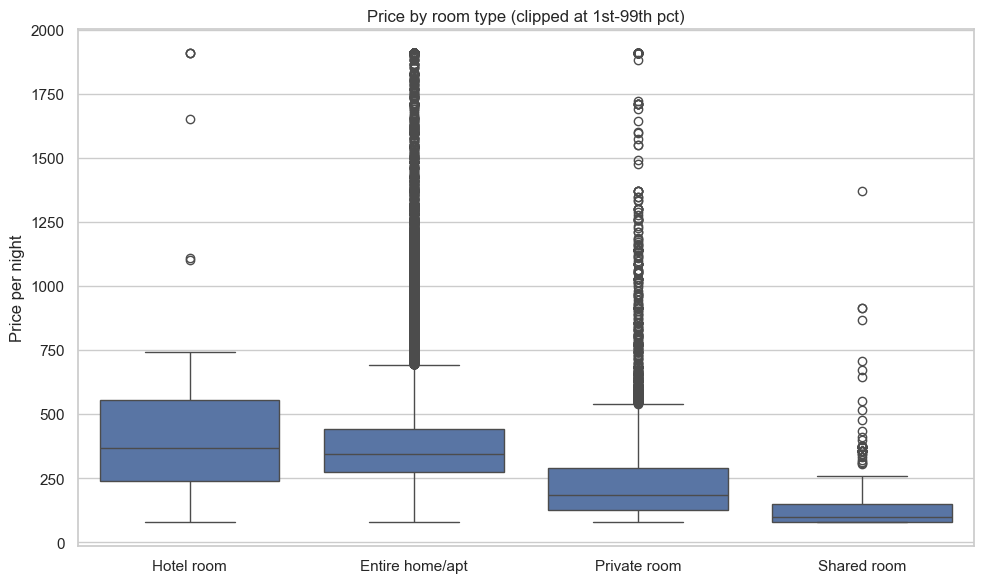

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
order = df_listings.groupby("room_type")["price_clean"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_listings.assign(price_trimmed=price_trimmed),
    x="room_type", y="price_trimmed", order=order, ax=ax,
)
ax.set_title("Price by room type (clipped at 1st-99th pct)")
ax.set_xlabel("")
ax.set_ylabel("Price per night")
plt.tight_layout()
plt.show()

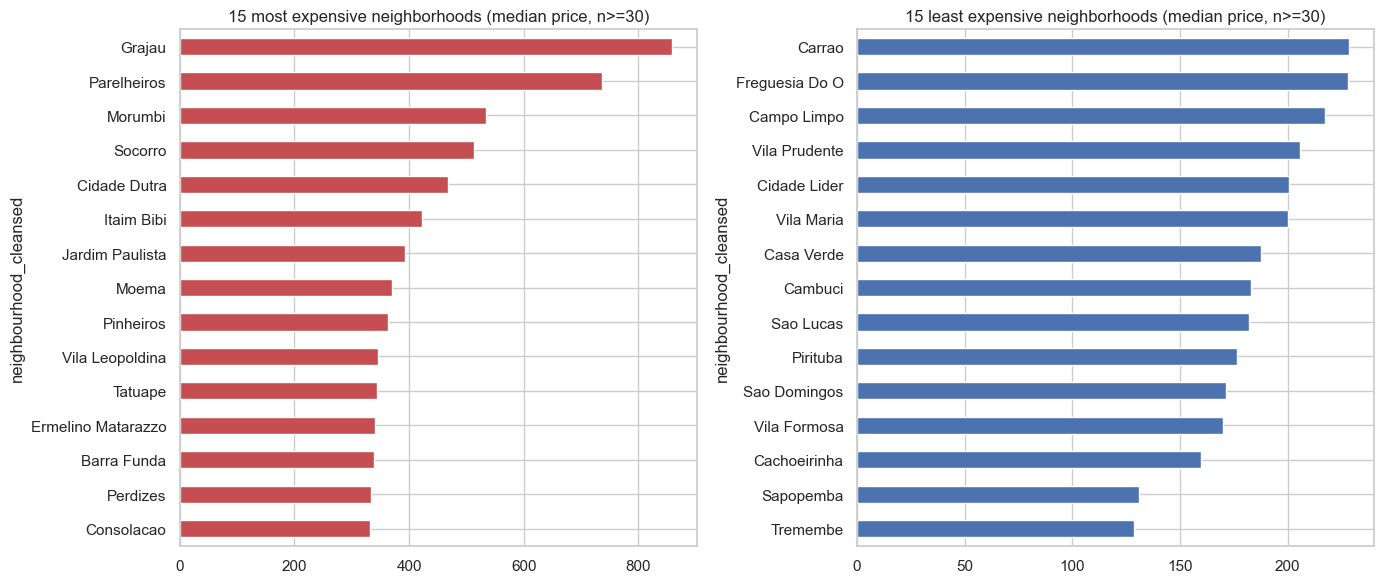

In [12]:
neigh_price = (
    df_listings.groupby("neighbourhood_cleansed")["price_clean"]
    .agg(median_price="median", n_listings="count")
    .query("n_listings >= 30")
    .sort_values("median_price", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
neigh_price.head(15)["median_price"].sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("15 most expensive neighborhoods (median price, n>=30)")

neigh_price.tail(15)["median_price"].sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("15 least expensive neighborhoods (median price, n>=30)")

plt.tight_layout()
plt.show()

## 8. Spatial distribution

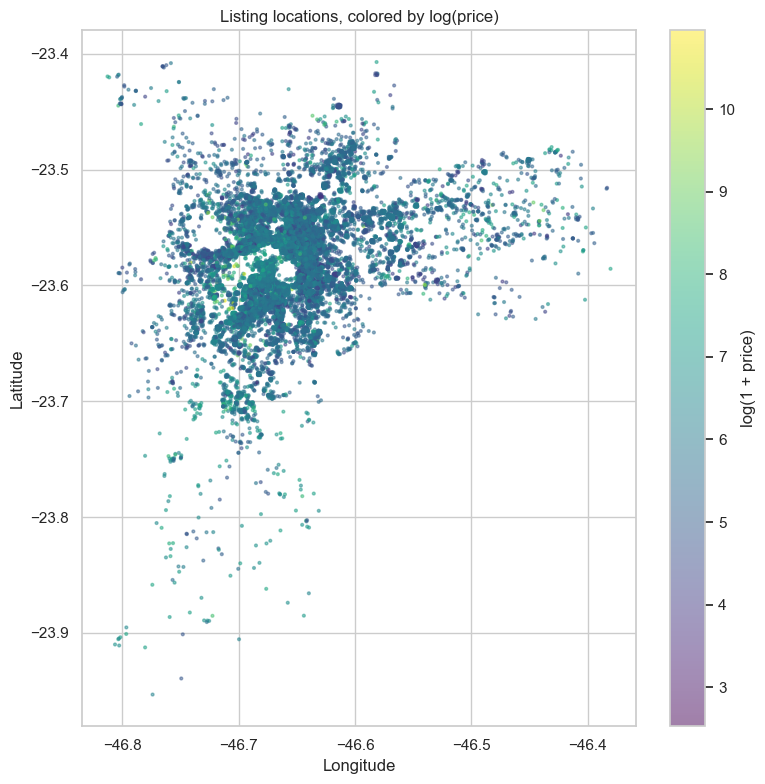

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    df_listings["longitude"], df_listings["latitude"],
    c=np.log1p(df_listings["price_clean"]), cmap="viridis", s=4, alpha=0.5,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Listing locations, colored by log(price)")
plt.colorbar(sc, ax=ax, label="log(1 + price)")
plt.tight_layout()
plt.show()

## 9. Capacity, bedrooms, and price

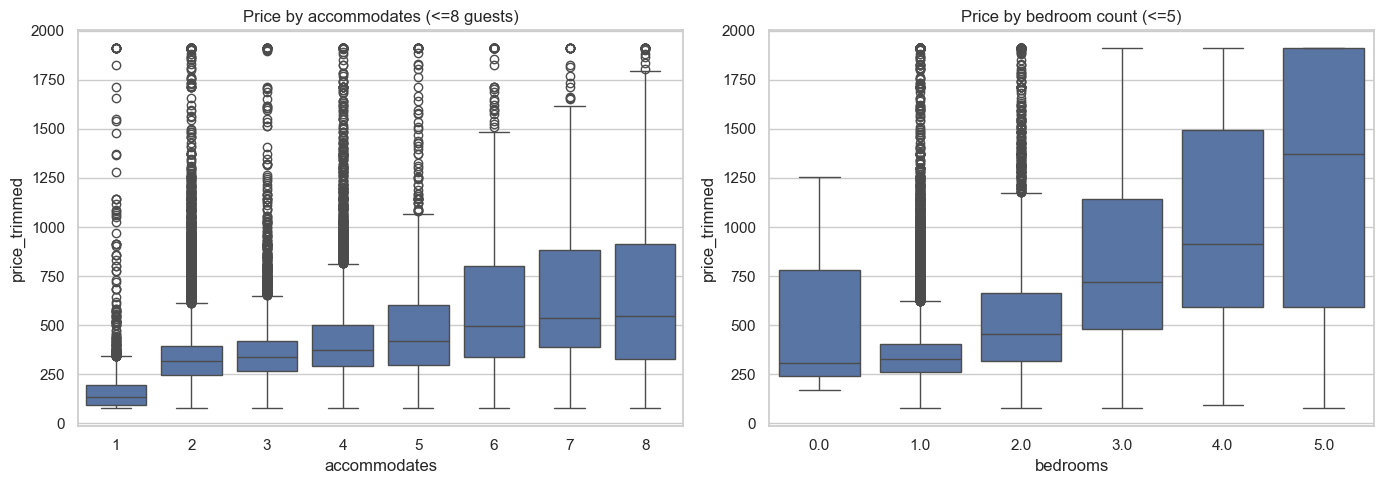

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_listings.assign(price_trimmed=price_trimmed).query("accommodates <= 8"),
    x="accommodates", y="price_trimmed", ax=axes[0],
)
axes[0].set_title("Price by accommodates (<=8 guests)")

sns.boxplot(
    data=df_listings.assign(price_trimmed=price_trimmed).query("bedrooms <= 5"),
    x="bedrooms", y="price_trimmed", ax=axes[1],
)
axes[1].set_title("Price by bedroom count (<=5)")

plt.tight_layout()
plt.show()

## 10. Reviews & host quality signals

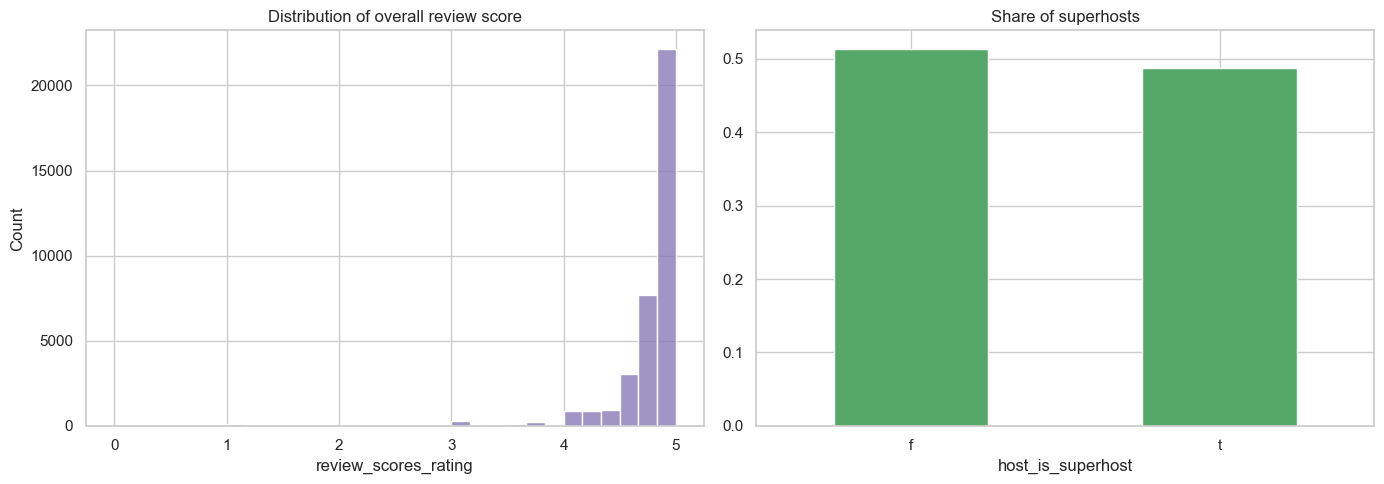

                      price_clean  review_scores_rating  number_of_reviews
price_clean              1.000000              0.001789          -0.041444
review_scores_rating     0.001789              1.000000           0.096923
number_of_reviews       -0.041444              0.096923           1.000000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_listings["review_scores_rating"].dropna(), bins=30, ax=axes[0], color="#8172B2")
axes[0].set_title("Distribution of overall review score")

superhost_share = df_listings["host_is_superhost"].value_counts(normalize=True, dropna=True)
superhost_share.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Share of superhosts")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

corr = df_listings[["price_clean", "review_scores_rating", "number_of_reviews"]].corr()
print(corr)

## 11. Availability & estimated revenue (from the listings snapshot)

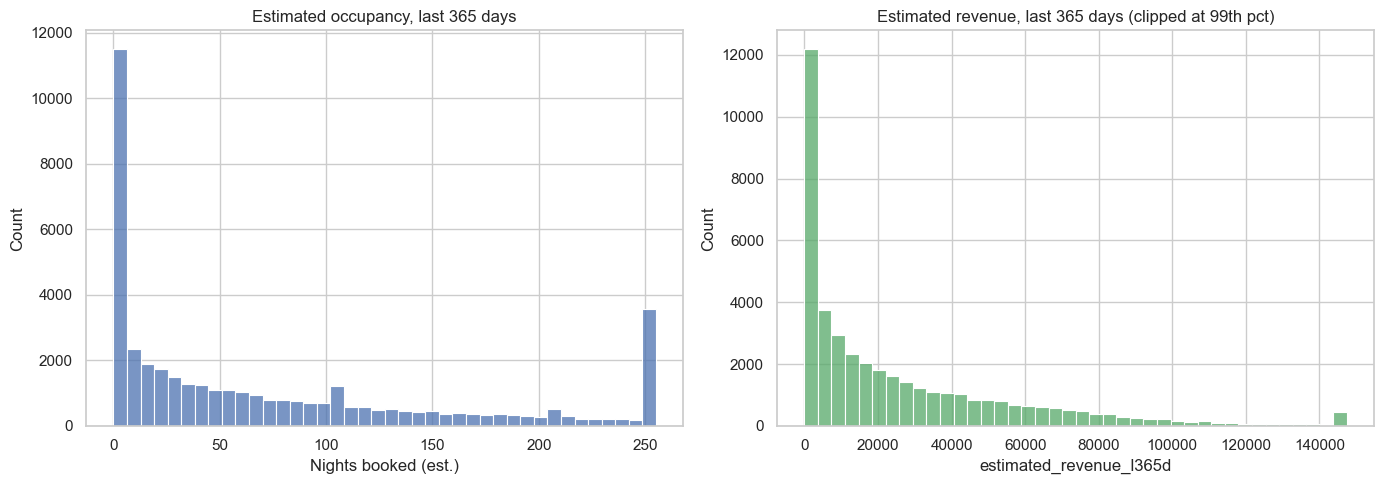

Correlation of price with occupancy/revenue proxies:
price_clean                  1.000000
estimated_occupancy_l365d   -0.068814
estimated_revenue_l365d      0.227839
availability_365             0.021273
Name: price_clean, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_listings["estimated_occupancy_l365d"].dropna(), bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Estimated occupancy, last 365 days")
axes[0].set_xlabel("Nights booked (est.)")

rev_trimmed = df_listings["estimated_revenue_l365d"].clip(
    upper=df_listings["estimated_revenue_l365d"].quantile(0.99)
)
sns.histplot(rev_trimmed.dropna(), bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Estimated revenue, last 365 days (clipped at 99th pct)")

plt.tight_layout()
plt.show()

print("Correlation of price with occupancy/revenue proxies:")
print(
    df_listings[
        ["price_clean", "estimated_occupancy_l365d", "estimated_revenue_l365d", "availability_365"]
    ].corr()["price_clean"]
)

## 12. Correlation matrix of key numeric features

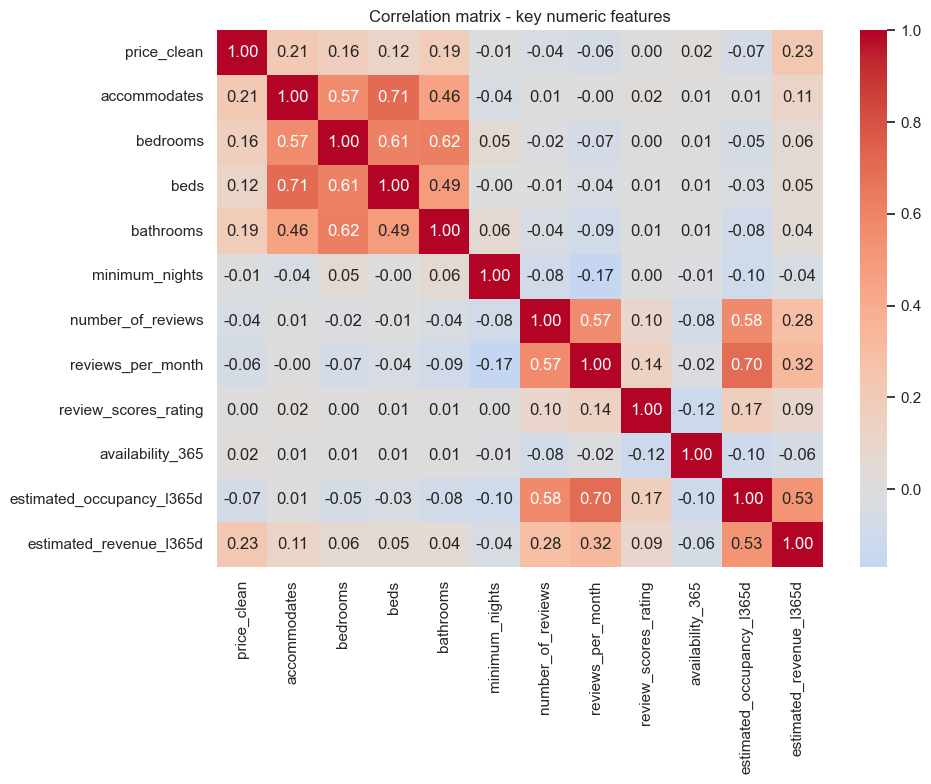

In [17]:
numeric_cols = [
    "price_clean", "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "review_scores_rating", "availability_365",
    "estimated_occupancy_l365d", "estimated_revenue_l365d",
]
corr = df_listings[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix - key numeric features")
plt.tight_layout()
plt.show()

## 13. Calendar: availability over the next 12 months

`calendar.csv` is large (~15.5M rows, ~550MB) — one row per listing per day for the year following the scrape. We read it in chunks and aggregate to a monthly availability rate instead of loading the full file into memory.

In [18]:
chunk_iter = pd.read_csv(
    DATA_DIR / "calendar.csv",
    usecols=["date", "available"],
    parse_dates=["date"],
    chunksize=2_000_000,
)

monthly_counts = None
for chunk in chunk_iter:
    chunk["month"] = chunk["date"].dt.to_period("M")
    chunk["is_available"] = chunk["available"].map({"t": 1, "f": 0})
    agg = chunk.groupby("month")["is_available"].agg(["sum", "count"])
    monthly_counts = agg if monthly_counts is None else monthly_counts.add(agg, fill_value=0)

monthly_availability = (monthly_counts["sum"] / monthly_counts["count"]).sort_index()
print(monthly_availability)

month
2026-06    0.620534
2026-07    0.750577
2026-08    0.849840
2026-09    0.822680
2026-10    0.748104
2026-11    0.781207
2026-12    0.747202
2027-01    0.716269
2027-02    0.713411
2027-03    0.646249
2027-04    0.604213
2027-05    0.602095
2027-06    0.585558
Freq: M, dtype: float64


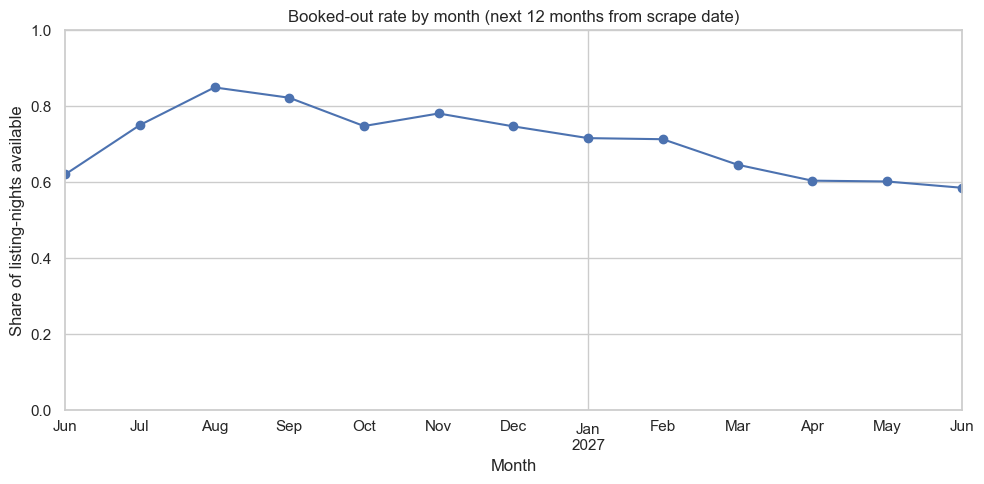

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
monthly_availability.plot(kind="line", marker="o", ax=ax, color="#4C72B0")
ax.set_ylabel("Share of listing-nights available")
ax.set_xlabel("Month")
ax.set_title("Booked-out rate by month (next 12 months from scrape date)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 14. Reviews volume over time

`reviews.csv` is also large (~1.6M rows, ~365MB) and mostly free text (`comments`). We only load `listing_id` and `date` here — text/sentiment analysis of `comments` is out of scope for this structural EDA.

reviews: (1577515, 2)  |  date range: 2011-04-19 to 2026-06-16


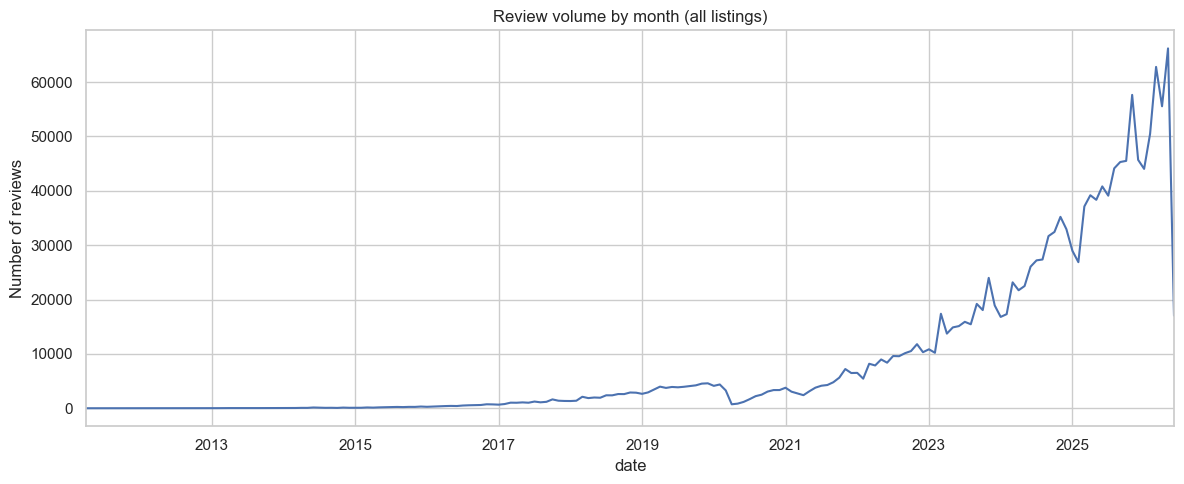

In [20]:
df_reviews = pd.read_csv(DATA_DIR / "reviews.csv", usecols=["listing_id", "date"], parse_dates=["date"])
print(f"reviews: {df_reviews.shape}  |  date range: {df_reviews['date'].min().date()} to {df_reviews['date'].max().date()}")

reviews_per_month = df_reviews["date"].dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
reviews_per_month.plot(ax=ax, color="#4C72B0")
ax.set_title("Review volume by month (all listings)")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

count    36604.000000
mean        43.096793
std         69.976108
min          1.000000
25%          6.000000
50%         19.000000
75%         52.000000
max       3314.000000
dtype: float64


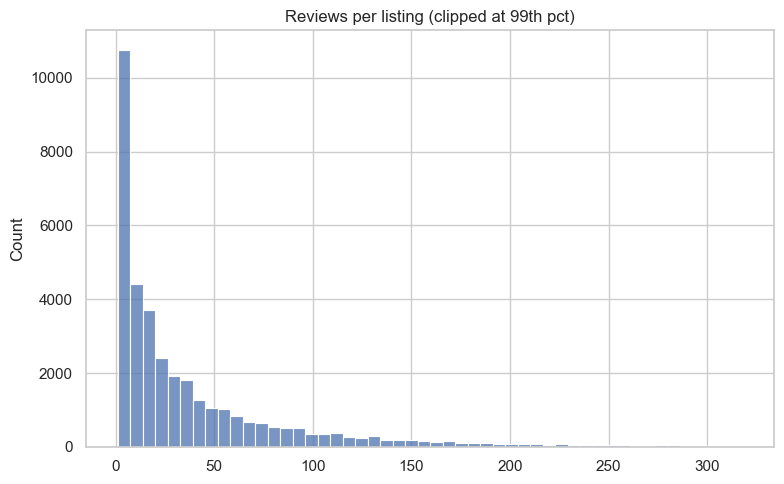

In [21]:
reviews_per_listing = df_reviews.groupby("listing_id").size()
print(reviews_per_listing.describe())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(reviews_per_listing[reviews_per_listing <= reviews_per_listing.quantile(0.99)], bins=50, ax=ax)
ax.set_title("Reviews per listing (clipped at 99th pct)")
plt.tight_layout()
plt.show()

## 15. Key findings & open questions

**Findings**
- The snapshot covers **42,354 listings**, scraped 2026-06-14/15/16, with a calendar horizon out to 2027-06-15.
- `price` needed cleaning (`"$540.43"` → `540.43`); after cleaning the distribution is strongly right-skewed, so `log1p(price)` is the better modeling target.
- 13 columns are 100% empty in this export (`host_since`, `license`, `instant_bookable`, `neighbourhood`, `host_verifications`, `calendar_updated`, etc.) — do not rely on them without re-scraping or another source.
- `Entire home/apt` dominates room types (~86% of listings); `Hotel room` is negligible (36 listings).
- Price rises with `accommodates` and `bedrooms` as expected, and varies substantially by neighborhood.
- `estimated_revenue_l365d`/`estimated_occupancy_l365d` correlate with price and are a reasonable revenue proxy for the hedonic model, but Inside Airbnb documents these as **estimates**, not verified bookings.
- Review scores cluster tightly near the top of the scale (typical Inside Airbnb pattern) — likely a weak standalone price predictor; more useful as a filter for review volume/recency.

**Open question — geographic scope mismatch**
- Neighborhood names and the lat/lon bounding box in this snapshot match **São Paulo**, not **Rio de Janeiro**. The rest of the project pipeline (ITBI/Data.Rio, ISP-RJ, FipeZAP, the stated research question) is scoped to Rio de Janeiro.
- **Action needed:** either (a) re-download the Rio de Janeiro Inside Airbnb export, or (b) consciously re-scope the project to São Paulo and update the other data sources accordingly. Logged in `02 - Data Sources/Inside Airbnb.md` and should be resolved before the spatial join step in [[05 - Methodology]].

**Next steps**
- Resolve the city-scope question above before any spatial join with ITBI/ISP-RJ.
- Decide on an outlier policy for `price` (currently just clipped for plotting, not for modeling).
- Revisit `estimated_revenue_l365d` vs. building a custom occupancy proxy from `calendar.csv` once availability data is joined at the region level.